## Lab Exercise Week \#5: Regression and SVM in Machine Learning

### Objective:
The goal of this lab exercise is to understand Linear Regression, Logistic Regression, SVMs and their application in machine learning. You will apply each of the mentioned regression models to the various datasest and use them to make predictions.

### Datasets:
For this lab exercise, you'll use the bike_sharing.csv, AthleteSelection.csv, HotelRevHelpfulnessV2.csv and weightV2.csv datasets from Brightspace.

### Libraries:
`scikit-learn` provides implementations of Linear and Logistic regression,  a gradient descent regressor and several flavours of a support vector classifier. You can find information on SVMs in sklearn here: https://scikit-learn.org/stable/modules/svm.html

### Tasks:

#### 1). Linear Regression:
<ul>
<li>Import all needed libraries.</li>
<li>Load the weightV2.csv dataset.</li>
<li>Explore the dataset to understand its structure and features.</li>
<li>Select approprate features for a your model.</li>
<li>Fit a linear regression model, make predictions and plot the prediction line on a scatter plot.</li>
</ul>

In [2]:
import pandas as pd
from sklearn.linear_model import SGDRegressor
weight_pd = pd.read_csv('weightV2.csv')
weight_pd.head()

,Weight,Waist
0,154.25,85.2
1,173.25,83.0
2,154.00,87.9
3,184.75,86.4
4,184.25,100.0


In [3]:
y = weight_pd.pop('Weight').values
X = weight_pd.values
X.shape

(251, 1)

In [6]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X, y)
print(' R squared statistic: {:.2f}'.format(reg.score(X, y)))
print(' Slope: {:.2f}'.format(reg.coef_[0]))
print(' Intercept: {:.2f}'.format(reg.intercept_))

 R squared statistic: 0.76
 Slope: 23.59
 Intercept: 178.19


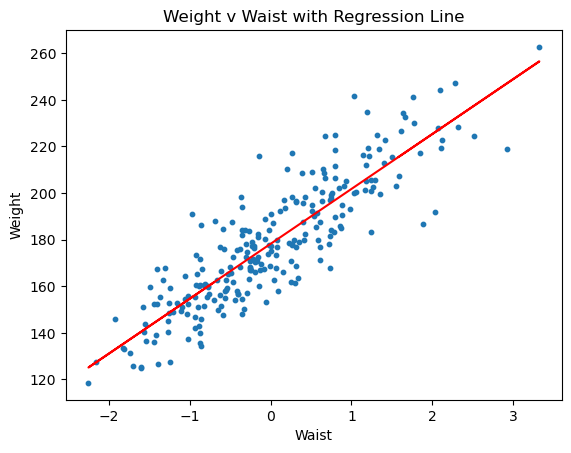

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
Y_pred = reg.predict(X)

plt.scatter(X, y, s = 10)
plt.plot(X, Y_pred, color='red')
plt.xlabel('Waist')
plt.ylabel('Weight')
plt.title ('Weight v Waist with Regression Line' )
plt.show()

#### 2). Multivariate Regression:
<ul>
<li>Load the bike_sharing.csv dataset.</li>
<li>Explore it and select features.</li>
<li>Use a standard scaler to fit your model and show your coefficients.</li>
<li>Use a stochastic gradient descent regressor and measure+compare results (MSE, MAE, RMSE).</li>
</ul>

In [10]:
bikes_df = pd.read_csv('bike_sharing.csv')
bikes_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [11]:
y = bikes_df.pop('count').values   # target values
#pop off features that are not useful
bikes_df.pop('casual')
bikes_df.pop('registered')
bikes_df.pop('instant')
bikes_df.pop('dteday')

X = bikes_df.values
X.shape

(731, 11)

In [12]:
bikes_df.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')

In [13]:
#Ordinary Least Squares regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
X_scal = StandardScaler().fit_transform(X)

reg = LinearRegression().fit(X_scal, y)
print(' R squared statistic: {:.3f}'.format(reg.score(X_scal, y)))
print(' Intercept: {:.2f}'.format(reg.intercept_))

 R squared statistic: 0.800
 Intercept: 4504.35


In [14]:
#print out the weights
for i,j in zip(reg.coef_, bikes_df.columns):
    print(i,j)

565.874453379889 season
1020.3507460886636 yr
-134.4619910961302 mnth
-86.69260451551581 holiday
138.36029286893705 weekday
55.95577694359975 workingday
-332.69556803804346 weathersit
371.14099460440843 temp
581.9065590011728 atemp
-145.01623946104468 hum
-198.07054397855822 windspeed


In [15]:
#Stochastic Gradient Descent Regressor
from sklearn.linear_model import SGDRegressor
SGD = SGDRegressor(max_iter=50, tol=1e-3).fit(X_scal, y)
print(' R squared statistic: {:.3f}'.format(SGD.score(X_scal, y)))
print(' Intercept: {:.2f}'.format(SGD.intercept_[0]))

 R squared statistic: 0.800
 Intercept: 4499.48


In [16]:
for i,j in zip(SGD.coef_, bikes_df.columns):
    print(i,j)

563.8667683492081 season
1020.1529142942381 yr
-128.5224204932605 mnth
-83.46190434291923 holiday
131.32270430632988 weekday
53.264559011219475 workingday
-332.1055087555006 weathersit
446.65439265617704 temp
506.0924502141112 atemp
-146.54411664375363 hum
-200.8613185924072 windspeed


In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

def RMSE(y_true, y_pred): 
    return np.sqrt(mean_squared_error(y_true, y_pred))

print('MSE: %.2f'
      % mean_squared_error(y, SGD.predict(X_scal)))
print('MAE: %.2f'
      % mean_absolute_error(y, SGD.predict(X_scal)))
print('RMSE: %.2f'
      % RMSE(y, SGD.predict(X_scal)))

MSE: 748821.74
MAE: 644.89
RMSE: 865.34


#### 3). Logistic Regression:
<ul>
<li>Load the AthleteSelection.csv dataset.</li>
<li>Explore it and select features.</li>
<li>Fit a logistic regression model and show coefficients + r squared statistic.</li>
<li>Compare to results with standard scaler.</li>
</ul>

In [18]:
athlete_pd = pd.read_csv('AthleteSelection.csv')
athlete_pd.sort_values('Agility',inplace = True, ascending = False)
athlete_pd.head(5)

,Athlete,Speed,Agility,Selected
16,x17,5.40,9.50,Yes
13,x14,5.75,8.75,Yes
12,x13,8.25,8.50,Yes
3,x4,3.25,8.25,No
18,x19,7.50,8.00,Yes


In [19]:
y = athlete_pd.pop('Selected').values
athlete_pd.pop('Athlete')  # get rid of ids from dataset
X = athlete_pd.values
X.shape

(20, 2)

In [20]:
from sklearn.linear_model import LogisticRegression
lreg = LogisticRegression(solver='liblinear').fit(X, y)
print(' R squared statistic: {:.2f}'.format(lreg.score(X, y)))
print(' Speed: {:.2f} Agility: {:.2f}'.format(lreg.coef_[0][0],
                                              lreg.coef_[0][1]))
print(' Intercept: {:.2f}'.format(lreg.intercept_[0]))

 R squared statistic: 0.85
 Speed: 0.38 Agility: -0.05
 Intercept: -1.61


In [22]:
# Normalise the values and see the impact on performance on the training data
from sklearn.preprocessing import StandardScaler
X_scal = StandardScaler().fit_transform(X)
lreg = LogisticRegression(solver='liblinear').fit(X_scal, y)
print(' R squared statistic: {:.2f}'.format(lreg.score(X_scal, y)))
print(' Speed: {:.2f} Agility: {:.2f}'.format(lreg.coef_[0][0],lreg.coef_[0][1]))
print(' Intercept: {:.2f}'.format(lreg.intercept_[0]))

 R squared statistic: 0.95
 Speed: 1.76 Agility: 0.83
 Intercept: -0.37


In [23]:
X_scal[:5]

array([[ 0.37882399,  1.6692244 ],
       [ 0.5843874 ,  1.3274037 ],
       [ 2.05269746,  1.21346347],
       [-0.88392265,  1.09952324],
       [ 1.61220444,  0.98558301]])

#### 4). SVMs:
<ul>
<li>Load libraries and the HotelRevHelpfulnessV2.csv dataset.</li>
<li>Explore it, get an overview of overall, positive and negative samples, and select features.</li>
<li>Use a standard scaler and create a test/train split.</li>
<li>Fit your model and make predictions on a linear kernel.</li>
<li>Measure accuracy and create a classification report</li>
</ul>

In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score

In [28]:
hotel_rev = pd.read_csv('HotelRevHelpfulnessV2.csv')
hotel_rev.head()

,aveHelpfulnessRatioUser,stdevHelpfulnessRatioUser,pcReviewsExceedMinHelpfulnessSupport,numReviewsUser,numReviewsHotel,ratingUser,numberSubRatingsUser,subRatingMeanUser,subRatingStdevUser,aveRatingUser,...,completeness_2,completeness_3,numberTermsEntry,percentageAlphaCharsEntry,fractionUpperCaseCharsEntry,fractionYouVsIEntry,numberTermsSummaryQuote,percentageAlphaCharsSummaryQuote,fractionUpperCaseCharsSummaryQuote,reviewHelpfulness
0,1.000000,0.000000,0.666667,3,16,5,4,4.000000,0.000000,4.333333,...,0,1,182,0.788474,0.025703,0.500000,6,0.815789,0.096774,1
1,0.772487,0.377321,0.500000,12,233,5,0,0.000000,0.000000,4.333333,...,0,0,158,0.791888,0.012594,0.500000,1,1.000000,0.083333,1
2,0.715473,0.300437,0.833333,12,302,4,7,3.714286,0.755929,4.166667,...,0,3,59,0.799639,0.024831,0.333333,4,0.828571,0.034483,0
3,0.521250,0.481675,0.222222,36,6,1,4,1.000000,0.000000,3.527778,...,0,0,95,0.782212,0.029155,0.500000,2,0.800000,0.062500,0
4,0.603175,0.246926,1.000000,2,271,3,0,0.000000,0.000000,3.500000,...,0,0,43,0.805128,0.028662,0.000000,1,1.000000,0.142857,0


In [29]:
n = hotel_rev.shape[0]
np = hotel_rev['reviewHelpfulness'].sum()
nn = n - np
print('{} Samples'.format(n))
print('{} Positive \n{} Negative'.format(np,nn))

486 Samples
308 Positive 
178 Negative


In [30]:
y = hotel_rev.pop('reviewHelpfulness').values
Xraw = hotel_rev.values
scaler = StandardScaler()
X = scaler.fit_transform(Xraw)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=1/3)
print("X_test shape: ",X_test.shape)

X_test shape:  (162, 23)


In [31]:
svm = SVC(kernel = 'linear',C=1)   
hotel_rev_SVM = svm.fit(X_train, y_train)
y_dash = hotel_rev_SVM.predict(X_test)

In [32]:
acc = accuracy_score(y_test, y_dash)
print("Accuracy: {0:.2f}".format(acc)) 
confusion = confusion_matrix(y_test, y_dash)
print("Confusion matrix:\n{}".format(confusion)) 

Accuracy: 0.69
Confusion matrix:
[[30 32]
 [18 82]]


In [33]:
report = classification_report(y_test, y_dash, target_names = ['Not Helpful','Helpful'])
print("Report:\n{}".format(report)) 

Report:
              precision    recall  f1-score   support

 Not Helpful       0.62      0.48      0.55        62
     Helpful       0.72      0.82      0.77       100

    accuracy                           0.69       162
   macro avg       0.67      0.65      0.66       162
weighted avg       0.68      0.69      0.68       162

